# Interactive Segmentation with SAM3

[![image](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/opengeos/segment-geospatial/blob/main/docs/examples/sam3_interactive.ipynb)

This notebook demonstrates how to segment remote sensing images interactively using the Segment Anything Model 3 (SAM3).

## Installation

First, make sure you have the required dependencies installed:

In [1]:
%pip install "segment-geospatial[samgeo3]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of anyio to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.0/248.0 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 669.2/669.2 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.7/33.7 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.0/102.0 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.2/157.2 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 92.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━

In [2]:
%pip install transformers==5.0.0rc0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 35.0 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.23.2
    Uninstalling tokenizers-0.23.2:
      Successfully uninstalled tokenizers-0.23.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.17.0
    Uninstalling transformers-5.17.0:
      Successfully uninstalled transformers-5.17.0


## Import Libraries


In [3]:
import leafmap

from samgeo import SamGeo3, download_file

## Download Sample Data

Let's download a sample satellite image covering the University of California, Berkeley, for testing:


In [4]:
url = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/uc_berkeley.tif"
image_path = download_file(url)

Downloading...
From: https://huggingface.co/datasets/giswqs/geospatial/resolve/main/uc_berkeley.tif
To: /content/uc_berkeley.tif
100%|██████████| 12.7M/12.7M [00:00<00:00, 33.6MB/s]


In [5]:
m = leafmap.Map()
m.add_raster(image_path, layer_name="Satellite image")
m

Map(center=[37.87135, -122.25784999999999], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_i…

## Request access to SAM3

To use SAM3, you need to request access by filling out this form on Hugging Face: https://huggingface.co/facebook/sam3

Once you have access, uncomment the following code block and run it.

In [6]:
from google.colab import userdata
from huggingface_hub import login

try:
    # Retrieve your Hugging Face token from Colab Secrets securely
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token)
except Exception as e:
    print("Could not retrieve 'HF_TOKEN' from Colab secrets. Please ensure you have added it to the Secrets manager.")
    print(f"Error details: {e}")

## Initialize SAM3

When initializing SAM3, you can choose the backend from "meta", or "transformers".

In [7]:
sam3 = SamGeo3(
    backend="transformers", device=None, checkpoint_path=None, load_from_HF=True
)

Using cpu device and transformers backend


config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.44GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/799 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.64M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

## Set the image

You can set the image by either passing the image path or the image URL.

In [8]:
sam3.set_image(image_path)

## Generate masks with text prompt

In [9]:
sam3.generate_masks(prompt="building")

Found 42 objects.


In [10]:
sam3.save_masks("masks.tif")

Saved 42 mask(s) to masks.tif


## Show the results

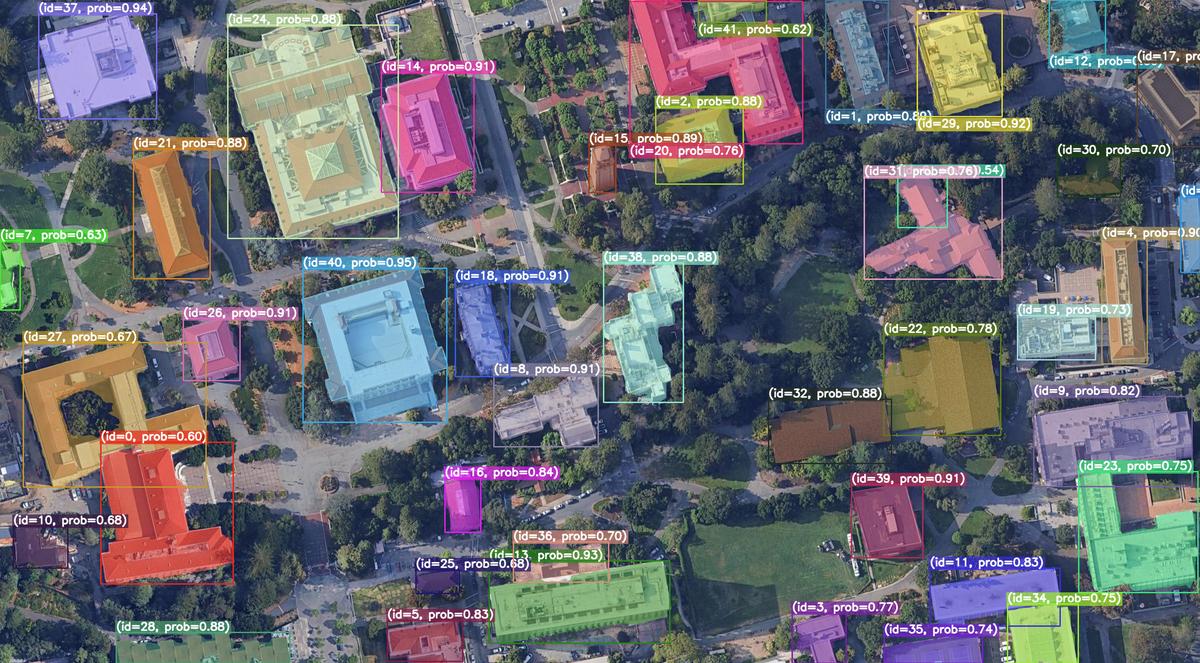

In [11]:
sam3.show_anns()

![annotation](https://github.com/user-attachments/assets/64323223-35a2-4e03-9cee-1b60fa0c12af)

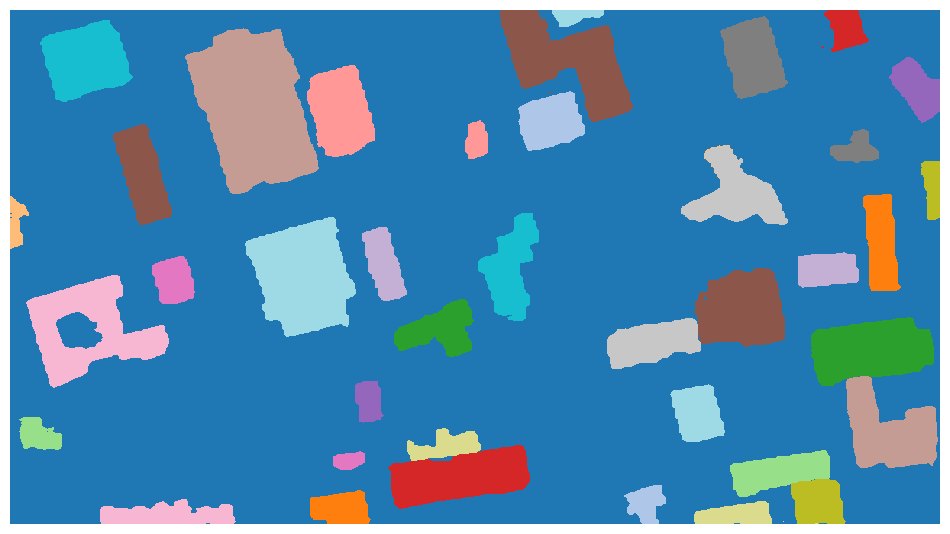

In [12]:
sam3.show_masks()

## Interactive segmentation

Enter a text prompt or draw a rectangle on the map, then click on the **Segment** button to perform instance segmentation.

In [13]:
sam3.show_map(height="700px", min_size=10)

Map(center=[37.87135, -122.25784999999999], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_i…

Segmentation by text prompts.

![image](https://github.com/user-attachments/assets/535d69b5-8e0f-46a3-8f8b-9fc602628a7f)

Segmentation by bounding boxes.

![](https://github.com/user-attachments/assets/3d6a5aed-8f3f-4350-ba26-04a84328c50d)